## Loading the required Libraries

In [46]:
import os
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential

In [4]:
dataset_path = 'Dataset'
train_dir = os.path.join(dataset_path, 'Training')
test_dir = os.path.join(dataset_path, 'Testing')

categories = ["glioma", "meningioma", "notumor", "pituitary"]

## Loading dataset

In [6]:
train_data = []

for category in categories:
    folder_path = os.path.join(train_dir, category)
    images = os.listdir(folder_path)
    count = len(images)
    train_data.append(pd.DataFrame({"Image" : images, "Category" : category, "Count" : [count] * count}))

train_df = pd.concat(train_data, ignore_index = True)

test_data = []
for category in categories:
    folder_path = os.path.join(test_dir, category)
    images = os.listdir(folder_path)
    test_data.append(pd.DataFrame({"Image" : images, "Category" : category }))

test_df = pd.concat(test_data, ignore_index = True)
train_df.head(10)

,Image,Category,Count
0,Tr-gl_1135.jpg,glioma,1321
1,Tr-gl_0559.jpg,glioma,1321
2,Tr-gl_1121.jpg,glioma,1321
3,Tr-gl_0217.jpg,glioma,1321
4,Tr-gl_1109.jpg,glioma,1321
5,Tr-gl_0571.jpg,glioma,1321
6,Tr-gl_0565.jpg,glioma,1321
7,Tr-gl_0203.jpg,glioma,1321
8,Tr-glTr_0003.jpg,glioma,1321
9,Tr-gl_0997.jpg,glioma,1321


## Visualizing the image of each category

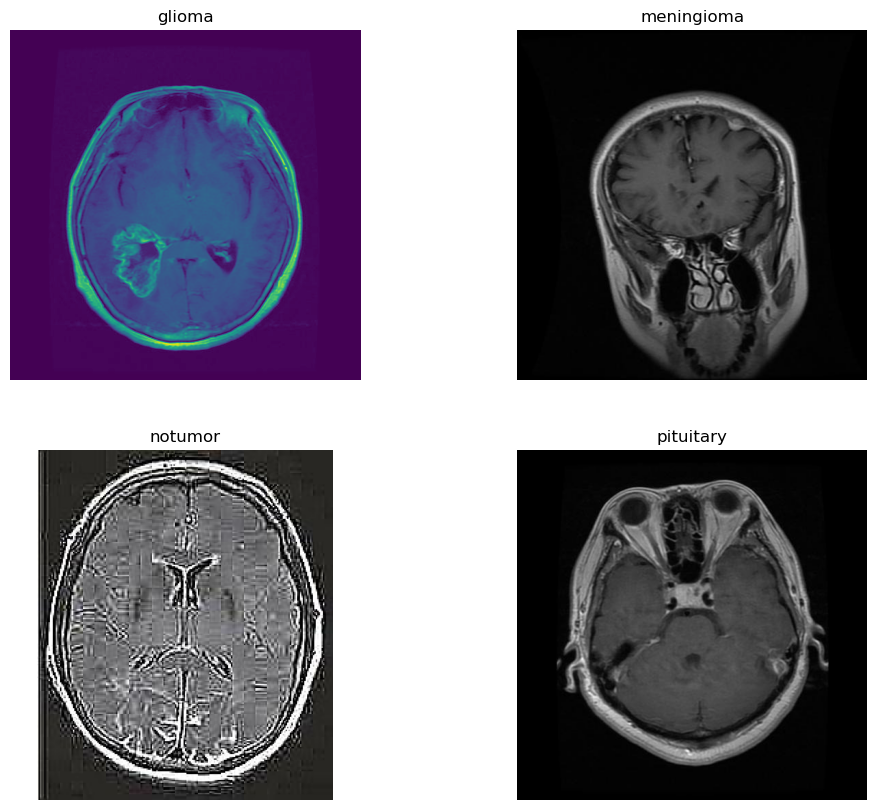

In [8]:
plt.figure(figsize = (12,10))

for i,category in enumerate(categories):
    folder_path = os.path.join(train_dir, category)
    image_path = os.path.join(folder_path, os.listdir(folder_path)[0])
    img = plt.imread(image_path)
    plt.subplot(2, 2, i+1)
    plt.title(category)
    plt.axis("off")
    plt.imshow(img)

plt.show()
    

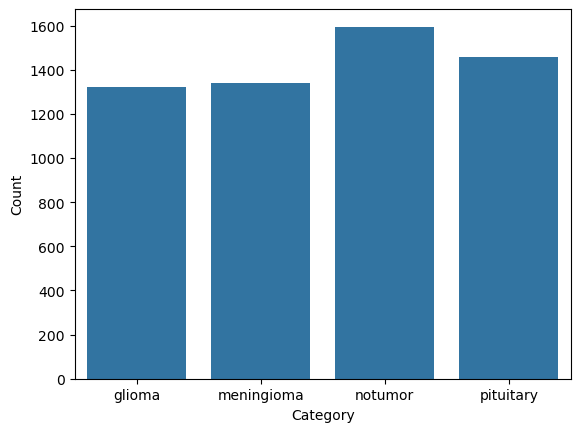

In [9]:
import seaborn as sns
sns.barplot(data = train_df, x = 'Category', y = 'Count')
plt.show()

## Image Size, Batch Size And Epochs

In [11]:
#image size
image_size = (150, 150)

#batch size
batch_size = 32

#epochs
epochs = 50

## Data Augmentation 

In [13]:
training_dataGen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest'
)

train_generator = training_dataGen.flow_from_directory(
    train_dir,
    target_size = image_size,
    batch_size = batch_size,
    class_mode = 'categorical'
)

test_dataGen = ImageDataGenerator(rescale = 1./255)

test_generator = test_dataGen.flow_from_directory(
    test_dir,
    target_size = image_size,
    batch_size = batch_size,
    class_mode = 'categorical'
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


## Building the model 

In [27]:
model = Sequential([
    Conv2D(32, (3, 3), activation = 'relu', input_shape = (image_size[0], image_size[1], 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3, 3), activation = 'relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation = 'relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation = 'relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation = 'relu'),
    Dropout(0.5),
    Dense(len(categories), activation = 'softmax')
])

model.compile(optimizer = 'adam', loss='categorical_crossentropy', metrics = ['accuracy'])

In [29]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 74, 74, 32)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 17, 17, 128)      0

In [31]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size
)

Epoch 1/50


2024-12-12 08:51:34.524202: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2024-12-12 08:51:34.562905: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


178/178 [==============================] - ETA: 0s - loss: 0.9921 - accuracy: 0.5641

2024-12-12 08:52:17.007966: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


178/178 [==============================] - 45s 253ms/step - loss: 0.9921 - accuracy: 0.5641 - val_loss: 1.3270 - val_accuracy: 0.5023
Epoch 2/50
178/178 [==============================] - 48s 270ms/step - loss: 0.7499 - accuracy: 0.7004 - val_loss: 0.9635 - val_accuracy: 0.6602
Epoch 3/50
178/178 [==============================] - 50s 282ms/step - loss: 0.6659 - accuracy: 0.7349 - val_loss: 1.4203 - val_accuracy: 0.5312
Epoch 4/50
178/178 [==============================] - 52s 289ms/step - loss: 0.5889 - accuracy: 0.7690 - val_loss: 0.6651 - val_accuracy: 0.7328
Epoch 5/50
178/178 [==============================] - 52s 293ms/step - loss: 0.5184 - accuracy: 0.8004 - val_loss: 0.7096 - val_accuracy: 0.7156
Epoch 6/50
178/178 [==============================] - 53s 296ms/step - loss: 0.4778 - accuracy: 0.8188 - val_loss: 0.5515 - val_accuracy: 0.7695
Epoch 7/50
178/178 [==============================] - 53s 299ms/step - loss: 0.4448 - accuracy: 0.8298 - val_loss: 0.8368 - val_accuracy: 0.7

## Accuracy 

In [41]:
loss, accuracy = model.evaluate(train_generator, steps = train_generator.samples // batch_size)
print(f"Train Accuracy : {accuracy}")

  1/178 [..............................] - ETA: 33s - loss: 0.0116 - accuracy: 1.0000

2024-12-12 09:47:41.396600: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


178/178 [==============================] - 21s 117ms/step - loss: 0.0670 - accuracy: 0.9745
Train Accuracy : 0.9745435118675232


In [36]:
loss, accuracy = model.evaluate(test_generator, steps = test_generator.samples // batch_size)
print(f"Test Accuracy : {accuracy}")

 2/40 [>.............................] - ETA: 2s - loss: 0.2292 - accuracy: 0.9062

2024-12-12 09:40:59.619538: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


40/40 [==============================] - 3s 74ms/step - loss: 0.1818 - accuracy: 0.9406
Test Accuracy : 0.940625011920929


## Confusion Matrix

In [52]:
predictions = model.predict(test_generator)
predicted_categories = np.argmax(predictions, axis = 1)
true_categories = test_generator.classes

confusion_matrix = tf.math.confusion_matrix(true_categories, predicted_categories)
print(confusion_matrix)

 2/41 [>.............................] - ETA: 2s

2024-12-12 09:58:26.880494: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


41/41 [==============================] - 3s 73ms/step
tf.Tensor(
[[ 60  69  99  72]
 [ 53  71 112  70]
 [ 81 113 112  99]
 [ 59  67 110  64]], shape=(4, 4), dtype=int32)


## Recall and Precision

In [59]:
recall_metric = tf.keras.metrics.Recall()
recall_metric.update_state(true_categories, predicted_categories)
recall_value = recall_metric.result().numpy()
print(recall_value)

0.8090999


In [61]:
precision_metric = tf.keras.metrics.Precision()
precision_metric.update_state(true_categories, predicted_categories)
precision_value = precision_metric.result().numpy()
print(precision_value)

0.7731569


Need to more focus on Recall to minimize false negatives, as missing a tumor can have life-threatening consequences. 